# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: data\wholesale_customers.csv
Dữ liệu đầy đủ: 440 dòng × 8 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [ ]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)

# 1. audit nhanh: kích thước, thiếu, trùng, và các cột ngữ cảnh
print("Kích thước:", df.shape)
print("Số dòng trùng:", df.duplicated().sum())
print("Tổng số giá trị thiếu:", df.isnull().sum().sum())
print("Cột ngữ cảnh (không dùng làm input clustering):",
      [c for c in df.columns if c not in SPENDING_FEATURES])

# 2. thống kê mô tả 6 cột chi tiêu (đơn vị gốc)
print("\nThống kê mô tả các cột chi tiêu:")
print(X_raw.describe().T.round(0))

# 3. độ lệch (skew) để biết dữ liệu lệch sao, càng lớn càng lệch phải
print("\nĐộ lệch (skew) từng cột")
print(X_raw.skew().sort_values(ascending=False).round(2))

Kích thước: (440, 8)
Số dòng trùng: 0
Tổng số giá trị thiếu: 0
Cột ngữ cảnh (không dùng làm input clustering): ['Channel', 'Region']

Thống kê mô tả các cột chi tiêu:
                  count      mean       std   min      25%      50%       75%  \
Fresh            440.00 12,000.00 12,647.00  3.00 3,128.00 8,504.00 16,934.00   
Milk             440.00  5,796.00  7,380.00 55.00 1,533.00 3,627.00  7,190.00   
Grocery          440.00  7,951.00  9,503.00  3.00 2,153.00 4,756.00 10,656.00   
Frozen           440.00  3,072.00  4,855.00 25.00   742.00 1,526.00  3,554.00   
Detergents_Paper 440.00  2,881.00  4,768.00  3.00   257.00   816.00  3,922.00   
Delicassen       440.00  1,525.00  2,820.00  3.00   408.00   966.00  1,820.00   

                        max  
Fresh            112,151.00  
Milk              73,498.00  
Grocery           92,780.00  
Frozen            60,869.00  
Detergents_Paper  40,827.00  
Delicassen        47,943.00  

Độ lệch (skew) từng cột, càng lớn càng lệch phải:
Deli

**Trả lời TODO A — Framing và audit:**

- Mỗi dòng là một khách hàng doanh nghiệp của nhà phân phối bán buôn, sáu cột `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen` là chi tiêu hằng năm cho từng nhóm hàng, đây chính là input cho bài toán phân nhóm.

- Dữ liệu sạch, không có dòng thiếu và không có dòng trùng, kiểu dữ liệu đều là số. Điểm cần lưu ý là dữ liệu lệch phải rất mạnh (skew của Delicassen tới hơn 11, Frozen gần 6), có một nhóm nhỏ khách chi rất cao tạo đuôi dài, đây là các điểm cực trị sẽ ảnh hưởng tới cách tính khoảng cách.

- `Channel` (Horeca hay Retail) và `Region` là thông tin ngữ cảnh. 

- Trong bối cảnh kinh doanh, một phân nhóm hữu ích nghĩa là các nhóm đủ khác biệt về hành vi chi tiêu để có thể đề xuất hành động riêng cho từng nhóm, ví dụ ưu đãi hay cách giao hàng khác nhau.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

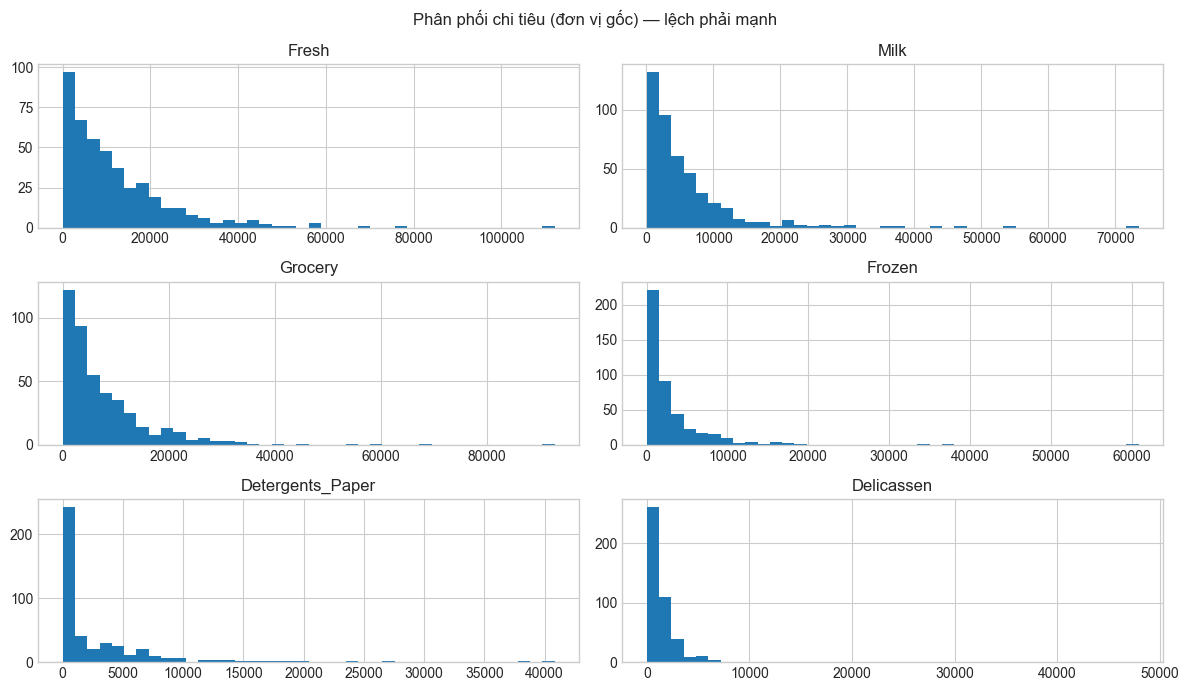

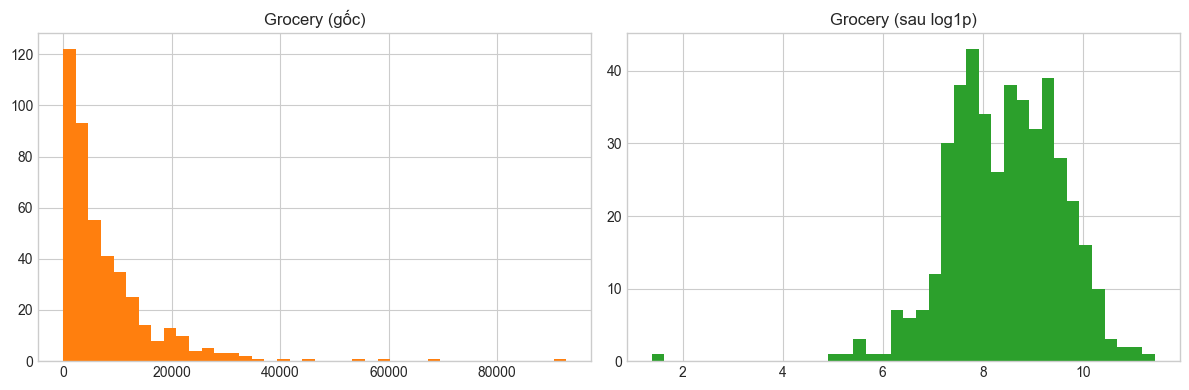

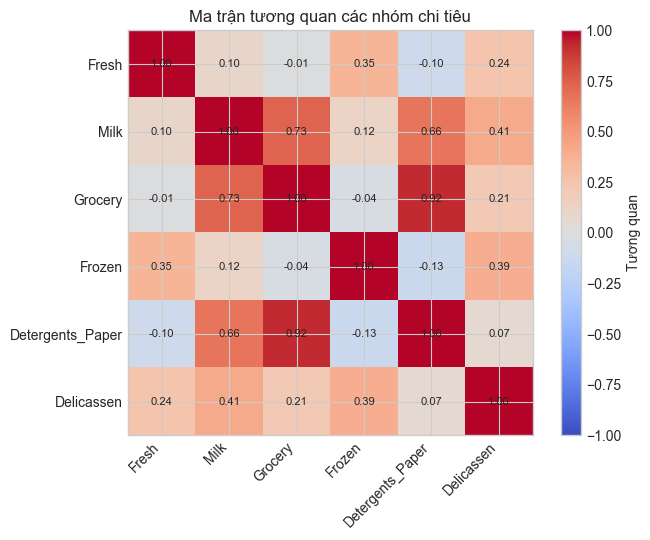

Tương quan cao nhất: Grocery và Detergents_Paper = 0.92


In [ ]:
# EDA có chủ đích cho TODO B

# 1. phân phối 6 cột chi tiêu ở đơn vị gốc, thấy lệch phải mạnh
X_raw.hist(bins=40, figsize=(12, 7))
plt.suptitle("Phân phối chi tiêu (đơn vị gốc)")
plt.tight_layout()
plt.show()

# 2. so sánh Grocery trước và sau khi lấy log để thấy log kéo dữ liệu về gần chuẩn hơn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_raw["Grocery"], bins=40, color="tab:orange"); axes[0].set_title("Grocery (gốc)")
axes[1].hist(np.log1p(X_raw["Grocery"]), bins=40, color="tab:green"); axes[1].set_title("Grocery (sau log1p)")
plt.tight_layout()
plt.show()

# 3. tương quan giữa các nhóm chi tiêu
corr = X_raw.corr()
plt.figure(figsize=(7, 5.5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Tương quan")
plt.xticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES, rotation=45, ha="right")
plt.yticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES)
for i in range(len(SPENDING_FEATURES)):
    for j in range(len(SPENDING_FEATURES)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Ma trận tương quan các nhóm chi tiêu")
plt.tight_layout()
plt.show()

print("Tương quan cao nhất: Grocery và Detergents_Paper =", round(corr.loc["Grocery", "Detergents_Paper"], 2))

**Nhận xét TODO B — EDA:**

- Cả sáu nhóm chi tiêu đều lệch phải rất mạnh, đa số khách chi ít nhưng một nhóm nhỏ chi rất nhiều, nếu để nguyên thì khoảng cách sẽ bị các giá trị lớn chi phối. Sau khi lấy log1p, phân phối cân đối hơn hẳn nên tính khoảng cách công bằng hơn giữa các khách.
- Các cột có thang đo rất khác nhau, Fresh và Grocery lớn hơn hẳn Delicassen, nên ngoài log còn cần chuẩn hóa để mọi feature đóng góp như nhau.
- `Grocery` và `Detergents_Paper` tương quan rất cao (khoảng 0.93), `Grocery` và `Milk` cũng cao (khoảng 0.73), cho thấy nhóm khách mua nhiều tạp hóa cũng mua nhiều sữa và đồ vệ sinh, đây là dấu hiệu của nhóm cửa hàng bán lẻ.
- Những quan sát này dẫn tới biểu diễn log1p rồi StandardScaler, và thử các thuật toán dựa trên khoảng cách như KMeans và phân cụm phân cấp.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [5]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

# giữ nguyên X_raw để profile cuối, tạo bản log rồi chuẩn hóa để fit model
X_log = np.log1p(X_raw)                              # giảm lệch phải, chi tiêu không âm nên log1p an toàn
X_model = StandardScaler().fit_transform(X_log)      # đưa các feature về cùng thang đo

print("X_raw giữ nguyên để profile:", X_raw.shape)
print("X_model (log1p + StandardScaler) để fit model:", X_model.shape)
print("Trung bình mỗi cột sau chuẩn hóa (xấp xỉ 0):", np.round(X_model.mean(axis=0), 2))
print("Độ lệch chuẩn mỗi cột (xấp xỉ 1):", np.round(X_model.std(axis=0), 2))

X_raw giữ nguyên để profile: (440, 6)
X_model (log1p + StandardScaler) để fit model: (440, 6)
Trung bình mỗi cột sau chuẩn hóa (xấp xỉ 0): [ 0. -0. -0.  0. -0. -0.]
Độ lệch chuẩn mỗi cột (xấp xỉ 1): [1. 1. 1. 1. 1. 1.]


**Nhận xét TODO C — Preprocessing:**

- Biểu diễn log1p rồi StandardScaler để fit model. Log1p xử lý độ lệch phải rất mạnh và làm dịu các điểm cực trị mà không phải xóa dữ liệu, dùng được vì chi tiêu luôn không âm. StandardScaler đưa sáu cột về cùng thang đo để không cột nào lấn át khi tính khoảng cách.Giữ nguyên `X_raw` để lúc profile cuối quay về đơn vị chi tiêu gốc cho dễ đọc. Một điểm đánh đổi là sau khi lấy log thì khoảng cách không còn theo đơn vị tiền gốc nữa nên khó diễn giải trực tiếp trên trục đã biến đổi, phải quay lại `X_raw` mới nói được con số cụ thể.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [6]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

# So sánh nhiều thuật toán trên cùng X_model
candidates = {}

# 1. KMeans với k = 2 và k = 3
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    candidates[f"KMeans_k{k}"] = km.fit_predict(X_model)

# 2. Phân cụm phân cấp (Agglomerative, ward) với k = 2 và k = 3
for k in [2, 3]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    candidates[f"Agglo_k{k}"] = agg.fit_predict(X_model)

# 3. DBSCAN thử hướng dựa trên mật độ
candidates["DBSCAN_eps1.5"] = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_model)

# tóm tắt số cụm và kích thước từng candidate
for name, lab in candidates.items():
    uniq = sorted(set(lab))
    n_noise = int((lab == -1).sum())
    sizes = {int(u): int((lab == u).sum()) for u in uniq}
    print(f"{name:16s} -> số cụm: {len(uniq) - (1 if -1 in uniq else 0)}, noise: {n_noise}, sizes: {sizes}")

KMeans_k2        -> số cụm: 2, noise: 0, sizes: {0: 252, 1: 188}
KMeans_k3        -> số cụm: 3, noise: 0, sizes: {0: 80, 1: 147, 2: 213}
Agglo_k2         -> số cụm: 2, noise: 0, sizes: {0: 178, 1: 262}
Agglo_k3         -> số cụm: 3, noise: 0, sizes: {0: 262, 1: 53, 2: 125}
DBSCAN_eps1.5    -> số cụm: 1, noise: 41, sizes: {-1: 41, 0: 399}


**Nhận xét TODO D — Khám phá model:**

- **KMeans** trên dữ liệu log chuẩn hóa cho các cụm cân đối, k=2 chia thành hai nhóm cỡ 252 và 188, k=3 chia nhỏ hơn thành 80, 147, 213. Đây là ứng viên chính vì cụm gọn và dễ diễn giải.
- **Phân cụm phân cấp (ward)** cho kết quả khá giống KMeans về cách chia nhóm, dùng để đối chiếu chéo, nếu hai thuật toán khác nhau cùng ra nhóm giống nhau thì tin cấu trúc nhóm là thật.
- **DBSCAN** không hợp với dữ liệu này, nó gộp gần hết vào một cụm và đẩy nhiều điểm thành nhiễu, vì mật độ dữ liệu khá liên tục, không có vùng trống rõ ràng để tách. Tớ loại DBSCAN.
- KMeans (k=2 và k=3) làm ứng viên chính và dùng Agglomerative để kiểm chứng, phần đánh giá tiếp theo sẽ chọn cấu hình cuối.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

KMeans theo k:
  k=2: silhouette=0.290, DB=1.352, inertia=1844
  k=3: silhouette=0.259, DB=1.341, inertia=1553
  k=4: silhouette=0.188, DB=1.541, inertia=1387
  k=5: silhouette=0.192, DB=1.484, inertia=1266
  k=6: silhouette=0.201, DB=1.432, inertia=1175


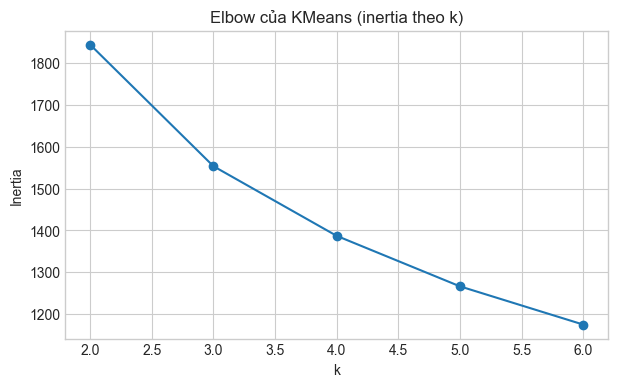

Ổn định KMeans k=2: ARI trung bình=1.000, thấp nhất=1.000
Ổn định KMeans k=3: ARI trung bình=0.982, thấp nhất=0.957

Đã chốt model cuối: KMeans k=2. Kích thước cụm: [252, 188]


In [7]:
# Đánh giá và kiểm tra độ ổn định cho TODO E

# 1. chất lượng nội bộ theo k cho KMeans (silhouette cao là tốt, Davies-Bouldin thấp là tốt)
print("KMeans theo k:")
inertias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_model)
    lab = km.labels_
    inertias.append(km.inertia_)
    print(f"  k={k}: silhouette={silhouette_score(X_model, lab):.3f}, "
          f"DB={davies_bouldin_score(X_model, lab):.3f}, inertia={km.inertia_:.0f}")

# 2. đường elbow
plt.figure(figsize=(7, 4))
plt.plot(range(2, 7), inertias, marker="o")
plt.title("Elbow của KMeans (inertia theo k)")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.show()

# 3. kiểm tra độ ổn định: đổi random seed nhiều lần, so nhãn bằng ARI (không phụ thuộc thứ tự label)
for k in [2, 3]:
    base = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X_model)
    aris = [adjusted_rand_score(base, KMeans(n_clusters=k, n_init=10, random_state=s).fit_predict(X_model))
            for s in range(1, 11)]
    print(f"Ổn định KMeans k={k}: ARI trung bình={np.mean(aris):.3f}, thấp nhất={np.min(aris):.3f}")

# chọn model cuối: KMeans k=2 trên X_model
labels_final = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_model)
print("\nĐã chốt model cuối: KMeans k=2. Kích thước cụm:", np.bincount(labels_final).tolist())

**Nhận xét TODO E — Đánh giá và chọn model:**

- **Chất lượng nội bộ:** k=2 cho silhouette cao nhất (khoảng 0.29), k=3 thấp hơn chút (khoảng 0.26) nhưng Davies-Bouldin gần bằng. Đường elbow cong nhẹ chứ không gãy rõ, nên số cụm không bị ép buộc, k=2 hoặc k=3 đều hợp lý.
- **Độ ổn định:** đây là bằng chứng mạnh nhất, KMeans k=2 hoàn toàn ổn định khi đổi seed (ARI trung bình bằng 1.0), k=3 cũng rất ổn định (ARI khoảng 0.98). Nghĩa là nhóm tìm được không phải do may rủi của một lần chạy.
- **Tính dùng được:** k=2 cho hai nhóm rõ ràng và dễ đặt tên, nên tớ chọn model cuối là KMeans k=2 trên dữ liệu log1p chuẩn hóa. Bằng chứng mạnh nhất là silhouette cao nhất cộng độ ổn định tuyệt đối.
- Ranh giới hai nhóm có phần chồng lấn (silhouette chỉ mức trung bình), nên vài khách ở giữa có thể bị xếp nhóm chưa thật chắc chắn.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


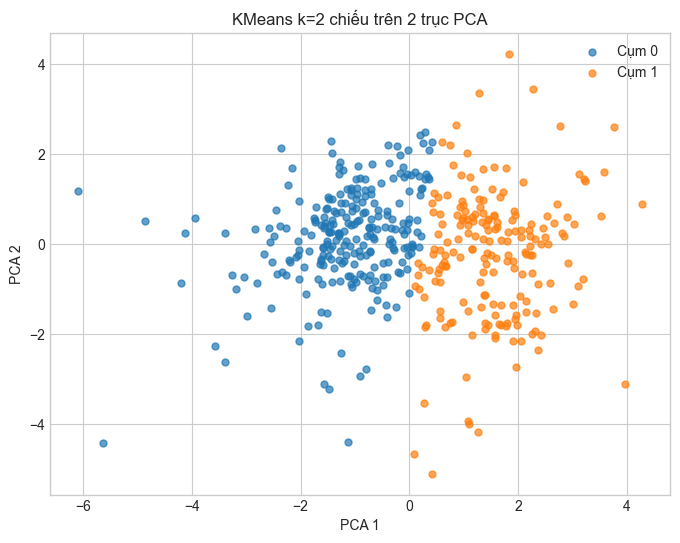

Tỷ lệ phương sai 2 trục PCA giữ lại: [0.441 0.272] -> tổng: 0.713


In [8]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

# chiếu dữ liệu nhiều chiều xuống 2 trục PCA để nhìn (model vẫn fit trên đủ 6 chiều của X_model)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

plt.figure(figsize=(8, 6))
for c in sorted(set(labels_final)):
    m = labels_final == c
    plt.scatter(coords[m, 0], coords[m, 1], s=25, alpha=0.7, label=f"Cụm {c}")
plt.title("KMeans k=2 chiếu trên 2 trục PCA")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.legend()
plt.show()

print("Tỷ lệ phương sai 2 trục PCA giữ lại:", np.round(pca.explained_variance_ratio_, 3),
      "-> tổng:", round(float(pca.explained_variance_ratio_.sum()), 3))

**Nhận xét TODO F — Visualize:**

- Biểu đồ PCA 2D giúp người đọc quan sát hai cụm có xu hướng nằm ở hai vùng khác nhau, một cụm lệch sang trái và một cụm lệch sang phải, cho thấy phân nhóm có cấu trúc thật chứ không phải chia bừa. Tuy nhiên hai trục PCA chỉ giữ lại một phần phương sai (xem tỉ lệ in ra), phần thông tin còn lại bị nén mất, nên không thể khẳng định từ hình này rằng hai cụm tách hoàn toàn hay các điểm ở vùng giáp ranh thuộc hẳn về nhóm nào. Model vẫn được fit trên đủ 6 chiều chứ không phải trên 2 trục PCA, PCA ở đây chỉ để trìn bày cho dễ nhìn.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [9]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

# profile bằng ĐƠN VỊ CHI TIÊU GỐC (median cho bền với outlier)
profile = X_raw.assign(cluster=labels_final).groupby("cluster").median().round(0)
print("Chi tiêu trung vị theo cụm (đơn vị gốc):")
print(profile.to_string())
print("\nSố khách mỗi cụm:", np.bincount(labels_final).tolist())

# kiểm chứng với biến ngữ cảnh Channel (1 = Horeca, 2 = Retail) bằng ARI
if "Channel" in df.columns:
    print("\nĐối chiếu cụm với Channel (ngữ cảnh, không dùng để train):")
    print(pd.crosstab(labels_final, df["Channel"]))
    print("ARI giữa cụm và Channel:", round(adjusted_rand_score(df["Channel"], labels_final), 3))

Chi tiêu trung vị theo cụm (đơn vị gốc):
            Fresh     Milk   Grocery   Frozen  Detergents_Paper  Delicassen
cluster                                                                    
0       10,348.00 1,871.00  2,406.00 2,225.00            328.00      750.00
1        5,406.00 7,690.00 11,527.00 1,062.00          4,495.00    1,388.00

Số khách mỗi cụm: [252, 188]

Đối chiếu cụm với Channel (ngữ cảnh, không dùng để train):
Channel    1    2
row_0            
0        244    8
1         54  134
ARI giữa cụm và Channel: 0.514


**Nhận xét TODO G — Profile, tên cụm và action:**

Dựa trên chi tiêu trung vị theo đơn vị gốc:

- **Cụm 0 — nhóm Nhà hàng, quán ăn (HoReCa)** (khoảng 252 khách): chi cho `Fresh` rất cao (trung vị khoảng 10.300) và `Frozen` khá cao, nhưng `Grocery`, `Milk`, `Detergents_Paper` đều thấp. Đây là hành vi của bên phục vụ ăn uống, mua nhiều đồ tươi và đông lạnh để chế biến.
- **Cụm 1 — nhóm Cửa hàng bán lẻ, tạp hóa (Retail)** (khoảng 188 khách): chi cho `Grocery` rất cao (khoảng 11.500), `Milk` và `Detergents_Paper` cũng cao, còn `Fresh` thấp hơn. Đây là hành vi của cửa hàng bán lại hàng khô, sữa và đồ gia dụng.

Đối chiếu với biến `Channel` cho ARI khoảng 0.51, nghĩa là hai cụm tìm được trùng khớp phần lớn với phân loại kênh Horeca và Retail có thật trong dữ liệu, đây là bằng chứng tốt cho thấy phân nhóm phản ánh một khác biệt kinh doanh thật.

Action hypothesis có thể kiểm chứng:
- Với cụm HoReCa, thử gói giao đồ tươi và đông lạnh thường xuyên hơn, đo bằng tỷ lệ đặt lại và doanh thu nhóm Fresh sau chiến dịch.
- Với cụm Retail, thử combo Grocery cộng Detergents_Paper và ưu đãi mua số lượng lớn, đo bằng giá trị đơn trung bình.

Dữ liệu còn thiếu trước khi ra quyết định: lợi nhuận từng nhóm hàng, tần suất và thời điểm đặt hàng, và phản hồi thực tế với các chương trình trước, vì chi tiêu cao chưa chắc đã là khách sinh lời cao.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## TODO H Tổng kết cho người ra quyết định

Nên thử nghiệm giới hạn phân nhóm này trước khi dùng rộng, vì nó ổn định và có ý nghĩa kinh doanh nhưng ranh giới chưa thật sắc nét. Model cuối là KMeans với k=2 trên dữ liệu đã lấy log1p rồi chuẩn hóa, bằng chứng mạnh nhất là silhouette cao nhất trong các lựa chọn và độ ổn định tuyệt đối khi đổi seed (ARI bằng 1.0), đồng thời hai cụm trùng phần lớn với biến kênh Channel có thật (ARI khoảng 0.51).

Hai insight quan trọng nhất từ profile. Thứ nhất, có một nhóm Nhà hàng quán ăn chi rất mạnh cho đồ tươi và đông lạnh nhưng ít mua tạp hóa. Thứ hai, có một nhóm Cửa hàng bán lẻ chi mạnh cho tạp hóa, sữa và đồ vệ sinh, hai nhóm này khác nhau rõ về cơ cấu chi tiêu chứ không chỉ về mức tổng.

Action nên thử trước là gói ưu đãi đồ tươi cho nhóm HoReCa và combo tạp hóa cộng đồ vệ sinh cho nhóm Retail, đánh giá bằng tỷ lệ đặt lại và giá trị đơn trung bình trên một nhóm thử so với nhóm đối chứng.

Giới hạn quan trọng nhất là dữ liệu chỉ có chi tiêu theo nhóm hàng, thiếu lợi nhuận, tần suất và thời gian, nên chi tiêu cao chưa chắc là khách giá trị cao, cần bổ sung các dữ liệu này trước khi biến phân nhóm thành quyết định lớn.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
